<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/clustering_Credit_Card_fradulent_Processed_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/Credit_Card_fradulent_Processed_data.csv'
df = pd.read_csv(url)
df.head()

,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,1,1,1,1,0,0,0,2,15,427500.0,32.868574,12.435574,0,2,2,1,2994,1
1,1,1,1,0,0,0,0,2,29,112500.0,58.793815,3.104787,0,0,0,0,182,0
2,0,0,1,0,1,1,0,1,4,270000.0,52.321403,8.353354,1,0,1,0,959,0
3,0,0,1,0,0,0,1,1,20,283500.0,61.504343,0.000000,2,2,3,0,2994,0
4,1,1,1,1,1,1,0,2,5,270000.0,46.193967,2.105450,0,2,0,0,300,0


In [ ]:
X = df.drop(columns=['Target'])
y = df['Target']

X_0 = X[y == 0]
X_1 = X[y == 1]

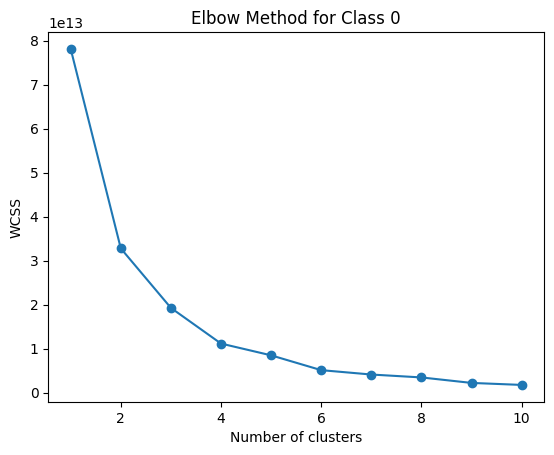

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

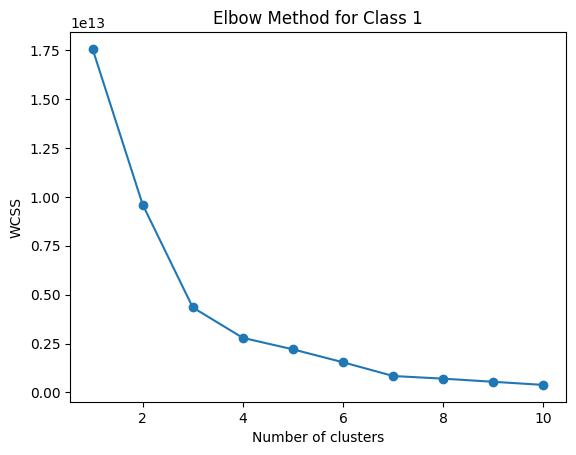

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 2   # <-- set based on elbow visualization
n_clusters_1 = 3   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42, n_init=10)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42, n_init=10)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 6834 samples
Class 0 - Cluster 1: 1592 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 825 samples
Class 1 - Cluster 1: 435 samples
Class 1 - Cluster 2: 23 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 8426 samples


In [ ]:
unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 1283 samples


Hierarchical Clustering

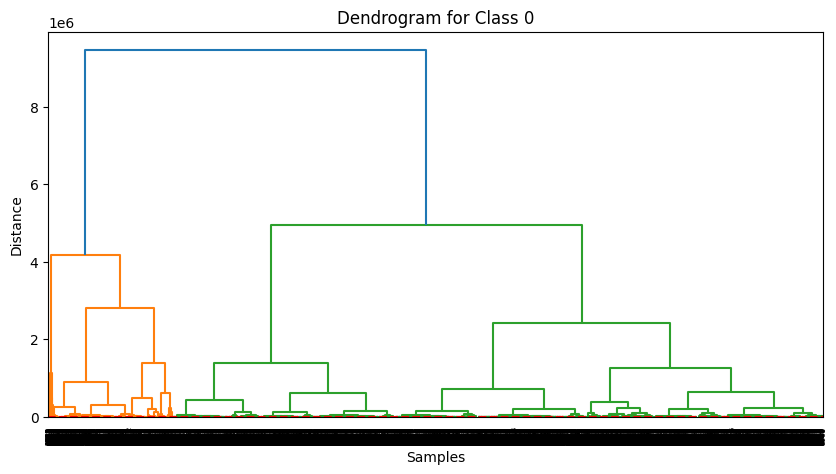

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 140


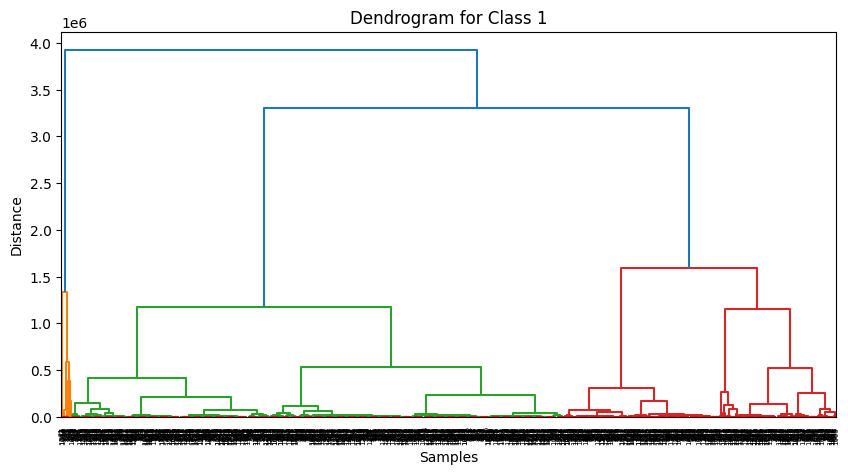

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 73


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 7076 samples
Class 0 - Cluster 1: 1350 samples
Class 1 - Cluster 0: 1265 samples
Class 1 - Cluster 1: 18 samples


Spectral Clustering

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score

In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Class 0 | n_clusters=2, Silhouette Score=-0.0299


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Class 0 | n_clusters=3, Silhouette Score=-0.4365


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


...

Class 1 | n_clusters=4, Silhouette Score=-0.4603


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Class 1 | n_clusters=5, Silhouette Score=-0.3753


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Class 1 | n_clusters=6, Silhouette Score=-0.3852
Best n_clusters for Class 1: 2 (Silhouette Score=-0.0326)


In [ ]:
# Show cluster counts
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1000 samples
Class 0 - Cluster 1: 7426 samples
Class 1 - Cluster 0: 1190 samples
Class 1 - Cluster 1: 93 samples


reclustering

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==============================
# STEP 0: Scale both class datasets
# ==============================
scaler = StandardScaler()
X_0_scaled = scaler.fit_transform(X_0)
X_1_scaled = scaler.fit_transform(X_1)

# ==============================
# STEP 1: Spectral clustering with silhouette-based best k
# ==============================
def run_spectral_clustering(X_data, class_label, k_range=(2, 7)):
    best_score = -1
    best_k = None
    best_labels = None
    scores = []

    for k in range(*k_range):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='rbf',          # ✅ use RBF to avoid "graph not fully connected" warning
            gamma=0.5,
            assign_labels='kmeans',
            random_state=42
        )

        labels = sc.fit_predict(X_data)

        # Skip invalid clustering (e.g., all in one cluster)
        if len(np.unique(labels)) < 2:
            print(f"Class {class_label} | n_clusters={k} → only one cluster found.")
            continue

        score = silhouette_score(X_data, labels)
        scores.append((k, score))
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"✅ Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    print(f"All silhouette scores for Class {class_label}: {scores}\n")

    return best_labels, best_k, best_score


# ==============================
# STEP 2: Reclustering large, dominant clusters
# ==============================
def recluster_large_groups(X_data, labels, class_label, size_threshold=0.75, recluster_k=3):
    """
    Recluster the largest cluster if it holds more than 'size_threshold' proportion of samples.
    """
    counts = np.bincount(labels)
    total = len(labels)
    largest_cluster = np.argmax(counts)
    largest_ratio = counts[largest_cluster] / total

    print(f"Class {class_label} - Largest cluster = {largest_cluster} ({largest_ratio*100:.2f}% of data)")

    new_labels = labels.copy()
    offset = labels.max() + 1  # prevent overlap between old and new labels

    if largest_ratio > size_threshold:
        idx_large = np.where(labels == largest_cluster)[0]
        X_large = X_data[idx_large]   # ✅ works for both np.array or DataFrame

        print(f"➡ Reclustering large cluster (size={len(X_large)}) into {recluster_k} subclusters...")
        sc = SpectralClustering(
             n_clusters=recluster_k,
               affinity='rbf',
                 gamma=1.0,                # 🔥 stronger separation
                assign_labels='kmeans',
             random_state=42
              )
        sub_labels = sc.fit_predict(X_large)
        new_labels[idx_large] = sub_labels + offset  # assign new unique labels

        print(f"✅ Reclustering done. Total clusters now: {new_labels.max() + 1}")

    return new_labels


# ==============================
# STEP 3: Display cluster distribution utility
# ==============================
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total samples: {total}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}\n")


# ==============================
# STEP 4: Run clustering
# ==============================
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0_scaled, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1_scaled, class_label=1)

# Show before reclustering
show_cluster_counts(sub_labels_0, 0)
show_cluster_counts(sub_labels_1, 1)

# ==============================
# STEP 5: Reclustering large clusters (if needed)
# ==============================
sub_labels_0_refined = recluster_large_groups(
    X_0_scaled, sub_labels_0, class_label=0,
    size_threshold=0.70, recluster_k=4   # increase k
)

sub_labels_1_refined = recluster_large_groups(
    X_1_scaled, sub_labels_1, class_label=1,
    size_threshold=0.70, recluster_k=4
)

# Show after reclustering
show_cluster_counts(sub_labels_0_refined, 0)
show_cluster_counts(sub_labels_1_refined, 1)



Class 0 | n_clusters=2, Silhouette Score=0.6719
Class 0 | n_clusters=3, Silhouette Score=0.6156
Class 0 | n_clusters=4, Silhouette Score=0.1556
Class 0 | n_clusters=5, Silhouette Score=0.1498
Class 0 | n_clusters=6, Silhouette Score=0.2875
✅ Best n_clusters for Class 0: 2 (Silhouette Score=0.6719)
All silhouette scores for Class 0: [(2, np.float64(0.6719174890867061)), (3, np.float64(0.6156293536954927)), (4, np.float64(0.15555496292854204)), (5, np.float64(0.14983496576724914)), (6, np.float64(0.28749921331980033))]

Class 1 | n_clusters=2, Silhouette Score=0.1903
Class 1 | n_clusters=3, Silhouette Score=0.1794
Class 1 | n_clusters=4, Silhouette Score=0.1647
Class 1 | n_clusters=5, Silhouette Score=0.1455
Class 1 | n_clusters=6, Silhouette Score=0.0291
✅ Best n_clusters for Class 1: 2 (Silhouette Score=0.1903)
All silhouette scores for Class 1: [(2, np.float64(0.19026644769262144)), (3, np.float64(0.1793869669811411)), (4, np.float64(0.16473505784032177)), (5, np.float64(0.14553178182

MiniBatchKMeans

In [ ]:
n_clusters_0 = 2
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 3
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1369 samples
Class 0 - Cluster 1: 7057 samples
Class 1 - Cluster 0: 817 samples
Class 1 - Cluster 1: 448 samples
Class 1 - Cluster 2: 18 samples


***reclustering

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial.distance import cdist

# ==============================
# STEP 0: Scale the data
# ==============================
scaler = StandardScaler()
X_0_scaled = scaler.fit_transform(X_0)
X_1_scaled = scaler.fit_transform(X_1)

# ==============================
# STEP 1: MiniBatchKMeans with slightly higher n_clusters
# ==============================
def run_soft_kmeans(X_data, n_clusters, class_label, batch_size=256):
    mbk = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=batch_size,
        max_iter=200,
        n_init=10,
        random_state=42
    )
    labels = mbk.fit_predict(X_data)
    counts = np.bincount(labels)
    print(f"\nInitial cluster distribution for Class {class_label}:")
    for i, c in enumerate(counts):
        print(f"Cluster {i}: {c} samples")
    return labels

labels_0 = run_soft_kmeans(X_0_scaled, n_clusters=4, class_label=0)
labels_1 = run_soft_kmeans(X_1_scaled, n_clusters=4, class_label=1)

# ==============================
# STEP 2: Recluster dominant clusters if too big
# ==============================
def recluster_large_clusters(X_data, labels, class_label, size_threshold=0.6, recluster_k=2):
    counts = np.bincount(labels)
    total = len(labels)
    largest_cluster = np.argmax(counts)
    largest_ratio = counts[largest_cluster] / total
    new_labels = labels.copy()
    offset = labels.max() + 1

    if largest_ratio > size_threshold:
        idx = np.where(labels == largest_cluster)[0]
        X_large = X_data[idx]
        print(f"\nClass {class_label} - reclustering large cluster {largest_cluster} ({largest_ratio*100:.2f}% of data)")
        mbk = MiniBatchKMeans(n_clusters=recluster_k, batch_size=256, random_state=42)
        sub_labels = mbk.fit_predict(X_large)
        new_labels[idx] = sub_labels + offset
        print(f"New total clusters: {new_labels.max() + 1}")
    return new_labels

labels_0 = recluster_large_clusters(X_0_scaled, labels_0, class_label=0, size_threshold=0.6, recluster_k=2)
labels_1 = recluster_large_clusters(X_1_scaled, labels_1, class_label=1, size_threshold=0.6, recluster_k=2)

# ==============================
# STEP 3: Merge tiny clusters
# ==============================
def merge_tiny_clusters(X_data, labels, min_size=50):
    counts = np.bincount(labels)
    new_labels = labels.copy()
    for cluster_idx, size in enumerate(counts):
        if size < min_size:
            idx = np.where(labels == cluster_idx)[0]
            # Find nearest cluster center
            other_labels = [i for i in np.unique(labels) if i != cluster_idx]
            centers = np.array([X_data[labels == i].mean(axis=0) for i in other_labels])
            dists = cdist(X_data[idx], centers)
            nearest_cluster = other_labels[np.argmin(dists.mean(axis=0))]
            new_labels[idx] = nearest_cluster
    return new_labels

labels_0 = merge_tiny_clusters(X_0_scaled, labels_0, min_size=50)
labels_1 = merge_tiny_clusters(X_1_scaled, labels_1, min_size=50)

# ==============================
# STEP 4: Display final cluster distribution
# ==============================
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total samples: {total}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}")

show_cluster_counts(labels_0, 0)
show_cluster_counts(labels_1, 1)



Initial cluster distribution for Class 0:
Cluster 0: 1713 samples
Cluster 1: 1515 samples
Cluster 2: 2247 samples
Cluster 3: 2951 samples

Initial cluster distribution for Class 1:
Cluster 0: 281 samples
Cluster 1: 405 samples
Cluster 2: 401 samples
Cluster 3: 196 samples

=== Cluster Distribution for Class 0 ===
Cluster 0: 1713 samples (20.33%)
Cluster 1: 1515 samples (17.98%)
Cluster 2: 2247 samples (26.67%)
Cluster 3: 2951 samples (35.02%)
Total samples: 8426
Balance Ratio (min/max): 0.513

=== Cluster Distribution for Class 1 ===
Cluster 0: 281 samples (21.90%)
Cluster 1: 405 samples (31.57%)
Cluster 2: 401 samples (31.25%)
Cluster 3: 196 samples (15.28%)
Total samples: 1283
Balance Ratio (min/max): 0.484


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

# ==============================
# STEP 0: Scale the data (assuming X_0 and X_1 are already defined)
# ==============================
scaler = StandardScaler()
X_0_scaled = scaler.fit_transform(X_0)
X_1_scaled = scaler.fit_transform(X_1)

# ==============================
# STEP 1: MiniBatchKMeans function
# ==============================
def run_soft_kmeans(X_data, n_clusters, class_label, batch_size=256):
    mbk = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=batch_size,
        max_iter=200,
        n_init=10,
        random_state=42
    )
    labels = mbk.fit_predict(X_data)
    counts = np.bincount(labels)
    print(f"\nInitial cluster distribution for Class {class_label}:")
    for i, c in enumerate(counts):
        print(f"Cluster {i}: {c} samples")
    return labels

# Get the initial 4-cluster labels for Class 0 and Class 1 using scaled data
labels_0 = run_soft_kmeans(X_0_scaled, n_clusters=4, class_label=0)
labels_1 = run_soft_kmeans(X_1_scaled, n_clusters=4, class_label=1)

# ==============================
# STEP 2: Relabel clusters to remove empty ones (if any) and ensure continuous indexing
# ==============================
def relabel_clusters(labels):
    """Reindex cluster labels (remove gaps and empty clusters)."""
    unique_labels = sorted([l for l in np.unique(labels) if np.sum(labels == l) > 0])
    label_map = {old: new for new, old in enumerate(unique_labels)}
    new_labels = np.array([label_map[l] for l in labels])
    return new_labels

sub_labels_0 = relabel_clusters(labels_0)
sub_labels_1 = relabel_clusters(labels_1)

# ==============================
# STEP 3: Create DataFrames for each class with original features and cluster labels
# ==============================
# Use the original X_0 and X_1 DataFrames to retain original column names and data
df_0_processed = X_0.copy()
df_0_processed['Cluster_Label'] = sub_labels_0
df_0_processed['Class'] = 0  # Assign original class (Target=0)

df_1_processed = X_1.copy()
df_1_processed['Cluster_Label'] = sub_labels_1
df_1_processed['Class'] = 1  # Assign original class (Target=1)

# ==============================
# STEP 4: Combine both datasets
# ==============================
final_df = pd.concat([df_0_processed, df_1_processed], ignore_index=False)

# ==============================
# STEP 5: Create continuous cluster numbering across both classes
# ==============================
# Get the maximum cluster label from Class 0 clusters
offset = final_df.loc[final_df['Class'] == 0, 'Cluster_Label'].max() + 1
# Add the offset to Class 1 cluster labels to make them unique
final_df.loc[final_df['Class'] == 1, 'Cluster_Label'] += offset

# ==============================
# STEP 6: Drop the temporary 'Class' column (if not needed in the final CSV)
# ==============================
final_df = final_df.drop(columns=['Class'])

# ==============================
# STEP 7: Save to CSV
# ==============================
final_df.to_csv("Clustered_Credit_Card_fradulent_Processed_data.csv", index=False)
print("✅ Clustered data saved successfully as 'Clustered_Credit_Card_fradulent_Processed_data.csv'")

# ==============================
# STEP 8: Optional summary
# ==============================
def show_cluster_counts(df):
    counts = df['Cluster_Label'].value_counts().sort_index()
    total = counts.sum()
    print("\n=== Final Cluster Distribution ===")
    for c, count in counts.items():
        pct = (count / total) * 100
        print(f"Cluster {c}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Clusters: {len(counts)}\n")

show_cluster_counts(final_df)



Initial cluster distribution for Class 0:
Cluster 0: 1713 samples
Cluster 1: 1515 samples
Cluster 2: 2247 samples
Cluster 3: 2951 samples

Initial cluster distribution for Class 1:
Cluster 0: 281 samples
Cluster 1: 405 samples
Cluster 2: 401 samples
Cluster 3: 196 samples
✅ Clustered data saved successfully as 'Clustered_Credit_Card_fradulent_Processed_data.csv'

=== Final Cluster Distribution ===
Cluster 0: 1713 samples (17.64%)
Cluster 1: 1515 samples (15.60%)
Cluster 2: 2247 samples (23.14%)
Cluster 3: 2951 samples (30.39%)
Cluster 4: 281 samples (2.89%)
Cluster 5: 405 samples (4.17%)
Cluster 6: 401 samples (4.13%)
Cluster 7: 196 samples (2.02%)
Total Samples: 9709
Clusters: 8



In [ ]:
import pandas as pd

# Load the clustered data
clustered_df = pd.read_csv("Clustered_Credit_Card_fradulent_Processed_data.csv")

# Rename the 'Cluster_Label' column to 'Target'
clustered_df.rename(columns={'Cluster_Label': 'Target'}, inplace=True)

# Display the head of the modified DataFrame
print("Head of the DataFrame with 'Target' column:")
print(clustered_df.head())

# Save the modified DataFrame to a new CSV file
clustered_df.to_csv("Clustered_Credit_Card_fradulent_Processed_data_renamed.csv", index=False)
print("\n✅ Modified clustered data saved successfully as 'Clustered_Credit_Card_fradulent_Processed_data_with_target.csv'")

Head of the DataFrame with 'Target' column:
   Gender  Own_car  Own_property  Work_phone  Phone  Email  Unemployed  \
0       1        1             1           0      0      0           0   
1       0        0             1           0      1      1           0   
2       0        0             1           0      0      0           1   
3       1        1             1           1      1      1           0   
4       1        1             1           0      0      0           0   

   Num_family  Account_length  Total_income        Age  Years_employed  \
0           2              29      112500.0  58.793815        3.104787   
1           1               4      270000.0  52.321403        8.353354   
2           1              20      283500.0  61.504343        0.000000   
3           2               5      270000.0  46.193967        2.105450   
4           2              17      135000.0  48.674511        3.269061   

   Income_type  Education_type  Family_status  Housing_type  Occup

reclustering

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=2)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0] k=2 -> silhouette=-0.0299


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0] k=3 -> silhouette=-0.4365


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0] k=5 -> silhouette=-0.0780


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0] k=6 -> silhouette=-0.5974
[0] Using forced_k=2 (silhouette=-0.0299)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=3)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1] k=2 -> silhouette=-0.0326


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1] k=3 -> silhouette=-0.4615


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1] k=5 -> silhouette=-0.3753


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1] k=6 -> silhouette=-0.3852
[1] Using forced_k=3 (silhouette=-0.4615)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 1000 samples
Class 0 - Cluster 1: 7426 samples
Class 1 - Cluster 0: 1260 samples
Class 1 - Cluster 1: 11 samples
Class 1 - Cluster 2: 12 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels


Re-clustering Class 0 - Cluster 0 into 3 sub-clusters


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0-0] k=2 -> silhouette=0.1390


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0-0] k=3 -> silhouette=0.1413


...

[0-1] k=5 -> silhouette=-0.4124


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[0-1] k=6 -> silhouette=-0.4743
[0-1] Using forced_k=3 (silhouette=-0.2854)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Class 0 - Original Cluster 0 -> Reclustered counts:
0    198
1    726
2     76
Name: count, dtype: int64
Class 0 - Original Cluster 1 -> Reclustered counts:
0    6780
1      49
2     597
Name: count, dtype: int64


In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0     198
1     726
2      76
3    6780
4      49
5     597
6    1260
7      11
8      12
Name: count, dtype: int64
